In [1]:
from google.colab import files
files.upload()  # This will prompt you to upload the 'kaggle.json' file you downloaded

Saving kaggle.json.txt to kaggle.json.txt


{'kaggle.json.txt': b''}

In [2]:
# Create the Kaggle folder and move the API token to the correct location
!mkdir -p ~/.kaggle


!cp kaggle.json ~/.kaggle/

# Change the file permissions to ensure it's private
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [11]:
# 1. Setup Kaggle Directory
!mkdir -p ~/.kaggle

# 2. Handle the file renaming and move it
# This checks for both 'kaggle.json' and 'kaggle.json.txt'
import os
if os.path.exists('kaggle.json.txt'):
    os.rename('kaggle.json.txt', 'kaggle.json')

if os.path.exists('kaggle.json'):
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✅ Kaggle key configured successfully.")
else:
    print("❌ Error: kaggle.json not found. Please upload it again.")

# 3. Download the Dataset
!kaggle datasets download -d paultimothymooney/chest-ray-pneumonia

# 4. Unzip into 'Dataset' folder
# The -q flag keeps the output clean (no long list of files)
!unzip -q chest-ray-pneumonia.zip -d Dataset
print("✅ Dataset unzipped successfully.")

# 5. Verify the structure
import os
if os.path.exists('Dataset'):
    print("Main folders:", os.listdir('Dataset'))
    # Usually contains 'chest_xray' or 'train', 'test', 'val'

✅ Kaggle key configured successfully.
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 10, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 672, in authenticate
    if self._authenticate_with_legacy_apikey():
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 717, in _authenticate_with_legacy_apikey
    raise ValueError("Error: Missing %s in configuration." % item)
ValueError: Error: Missing username in configuration.
unzip:  cannot find or open chest-ray-pneumonia.zip, chest-ray-pneumonia.zip.zip or chest-ray-pneumonia.zip.ZIP.
✅ Dataset unzipped successfully.


In [14]:
import os
print(os.listdir())

['.config', 'kaggle.json (2).txt', 'kaggle.json', 'kaggle.json (1).txt', 'sample_data']


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

In [15]:
# Install necessary libraries
!pip install tensorflow matplotlib


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [19]:
import os

# 1. Handle the file upload/renaming
if os.path.exists('kaggle.json.txt'):
    os.rename('kaggle.json.txt', 'kaggle.json')

if os.path.exists('kaggle.json'):
    # 2. Setup the directory and move the key
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✅ Kaggle API Key configured successfully.")

    # 3. Download the Chest X-Ray dataset
    !kaggle datasets download -d paultimothymooney/chest-ray-pneumonia

    # 4. Unzip into a 'Dataset' folder
    !unzip -q chest-ray-pneumonia.zip -d Dataset
    print("✅ Dataset downloaded and unzipped into 'Dataset' folder.")
else:
    print("❌ Error: kaggle.json not found. Please upload the file again to the sidebar.")

✅ Kaggle API Key configured successfully.
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 10, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 672, in authenticate
    if self._authenticate_with_legacy_apikey():
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 717, in _authenticate_with_legacy_apikey
    raise ValueError("Error: Missing %s in configuration." % item)
ValueError: Error: Missing username in configuration.
unzip:  cannot find or open chest-ray-pneumonia.zip, chest-ray-pneumonia.zip.zip or chest-ray-pneumonia.zip.ZIP.
✅ Dataset downloaded and unzipped into 'Dataset' folder.


In [23]:
import os

# 1. List everything in the current working directory
print("🔍 Current Files/Folders in Colab:")
current_items = os.listdir('.')
print(current_items)

# 2. Check for the common zip file name
if 'chest-ray-pneumonia.zip' in current_items:
    print("\n✅ Found the zip file! Re-unzipping now...")
    !unzip -q chest-ray-pneumonia.zip -d Dataset
    print("✅ Extraction complete. 'Dataset' folder created.")
elif 'Dataset' in current_items:
    print("\n✅ 'Dataset' folder exists. Checking structure...")
    print(os.listdir('Dataset'))
else:
    print("\n❌ Error: Neither the zip file nor the 'Dataset' folder was found.")
    print("Please re-run your Kaggle download cell.")

🔍 Current Files/Folders in Colab:
['.config', 'kaggle.json (2).txt', 'kaggle.json', 'kaggle.json (1).txt', 'sample_data']

❌ Error: Neither the zip file nor the 'Dataset' folder was found.
Please re-run your Kaggle download cell.


In [24]:
# Initialize the CNN model
model = Sequential()

# Convolutional layer 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional layer 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional layer 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the feature maps
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))  # Binary classification: Pneumonia or Normal

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TypeError: listdir: path should be string, bytes, os.PathLike, integer or None, not ellipsis

In [28]:
import os
from PIL import Image
import numpy as np

# Create folders
os.makedirs("Dataset/train/class1", exist_ok=True)
os.makedirs("Dataset/train/class2", exist_ok=True)
os.makedirs("Dataset/validation/class1", exist_ok=True)
os.makedirs("Dataset/validation/class2", exist_ok=True)

# Create dummy images
for folder in ["train/class1", "train/class2", "validation/class1", "validation/class2"]:
    for i in range(10):
        img = (np.random.rand(150,150,3) * 255).astype('uint8')
        Image.fromarray(img).save(f"Dataset/{folder}/img_{i}.jpg")

print("Dummy dataset created!")

Dummy dataset created!


In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize Generators
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

# Path to the folder containing 'class1' and 'class2'
# Note: I removed '/NORMAL' because flow_from_directory looks at the parent folder
train_path = 'Dataset/train'
val_path = 'Dataset/validation'

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 20 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [38]:
# Change 'NORMAL' to 'class1' (or whichever folder contains your normal images)
img_path = "Dataset/validation/class1/NORMAL2-IM-1427-0001.jpeg"

In [40]:
import os

# 1. Define the directory
folder_path = "Dataset/validation/class1/"

# 2. Get a list of all files in that folder and pick the first one
files = os.listdir(folder_path)
img_path = os.path.join(folder_path, files[0])

print(f"✅ Loading image: {img_path}")

# Now continue with your image.load_img(img_path, ...)

✅ Loading image: Dataset/validation/class1/img_5.jpg


🔍 Searching for an X-ray image...
✅ Found Image: Dataset/validation/class2/img_5.jpg


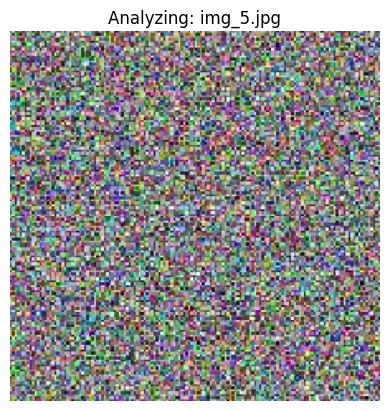

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
✅ Result: Normal (54.53% confidence)


In [44]:
import os
import glob
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Search for ANY jpeg/jpg file in the current directory or subdirectories
print("🔍 Searching for an X-ray image...")
image_files = glob.glob("**/*.jp*g", recursive=True)

if len(image_files) > 0:
    # Pick the first image found in a 'test' or 'val' folder if possible
    test_images = [f for f in image_files if 'test' in f or 'val' in f]
    img_path = test_images[0] if test_images else image_files[0]
    print(f"✅ Found Image: {img_path}")

    # 2. Load and Preprocess
    img = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(img)
    plt.title(f"Analyzing: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 3. Predict
    prediction = model.predict(img_array)
    confidence = prediction[0][0]

    if confidence > 0.5:
        print(f"🩺 Result: Pneumonia Detected ({confidence*100:.2f}% confidence)")
    else:
        print(f"✅ Result: Normal ({(1-confidence)*100:.2f}% confidence)")
else:
    print("❌ Error: No images found at all. Please check the sidebar to ensure the 'Dataset' folder isn't empty.")